# Interpretabilidad del Modelo : Random Forest (2018-2024)

Este notebook genera las visualizaciones de interpretabilidad del modelo
Random Forest seleccionado, incluyendo SHAP values y árbol de decisión individual.
Estas visualizaciones documentan cómo el modelo toma sus decisiones predictivas.


In [2]:
# -- Importaciones ----------------------------------------------
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.tree import export_graphviz, plot_tree
import warnings

warnings.filterwarnings('ignore')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


## 1. Carga del modelo y datos

In [3]:
# -- Carga del modelo y datos ----------------------------------------------
rf = joblib.load('../data/models/random_forest.pkl')

test = pd.read_parquet('../data/clean/test.parquet')

FEATURES = ['tipo_eve','tipo_veh','g_hora_5','dia_sem_ocu',
            'sexo_per','edad_quinquenales','mayor_menor','depto_ocu']
TARGET = 'fall_les'

X_test = test[FEATURES]
y_test = test[TARGET]

print(f'✓ Modelo cargado — {rf.n_estimators} árboles')
print(f'✓ Test set: {X_test.shape[0]:,} registros × {X_test.shape[1]} features')

✓ Modelo cargado — 200 árboles
✓ Test set: 14,389 registros × 8 features


## 2. Árbol de decisión individual

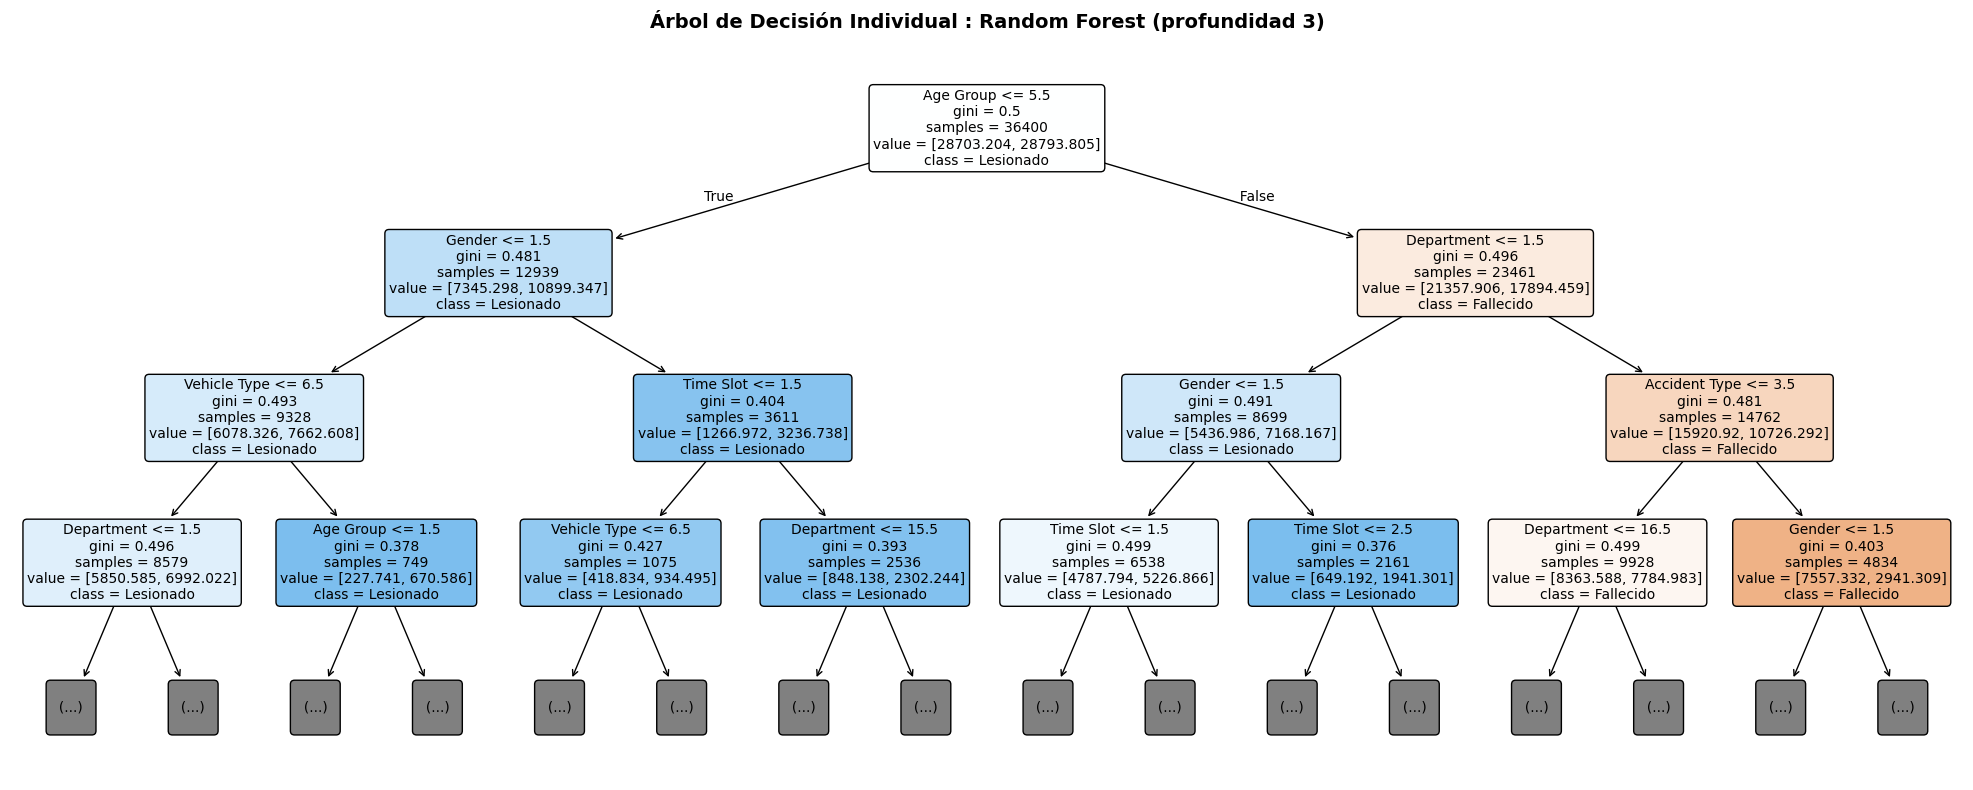

✓ Árbol guardado en data/models/arbol_decision.png


In [4]:
LABELS = {
    'tipo_eve'         : 'Accident Type',
    'tipo_veh'         : 'Vehicle Type',
    'g_hora_5'         : 'Time Slot',
    'dia_sem_ocu'      : 'Day of the Week',
    'sexo_per'         : 'Gender',
    'edad_quinquenales': 'Age Group',
    'mayor_menor'      : 'Age Status (Minor/Adult)',
    'depto_ocu'        : 'Department'
}

fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    rf.estimators_[0],
    feature_names=[LABELS[f] for f in FEATURES],
    class_names=['Fallecido', 'Lesionado'],
    filled=True,
    rounded=True,
    max_depth=3,
    ax=ax,
    fontsize=10
)

ax.set_title('Árbol de Decisión Individual : Random Forest (profundidad 3)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../data/models/arbol_decision.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Árbol guardado en data/models/arbol_decision.png')

### Interpretación del árbol de decisión

El primer nodo discriminador es **Rango de edad** (<=5.5 = grupos 1-5, menores de 25 años).
Para víctimas jóvenes el segundo factor es el **Sexo**.
Para víctimas mayores el segundo factor es el **Departamento**.
Los nodos naranjas indican mayor probabilidad de Fallecido.

## 3. SHAP Values : Interpretabilidad global

In [5]:
# -- Calcular SHAP  ----------------------------------------------
X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_sample)

print(f'✓ SHAP values calculados')
print(f'  Shape: {shap_values.shape}')
print(f'  Tipo: {type(shap_values)}')

✓ SHAP values calculados
  Shape: (500, 8, 2)
  Tipo: <class 'shap._explanation.Explanation'>


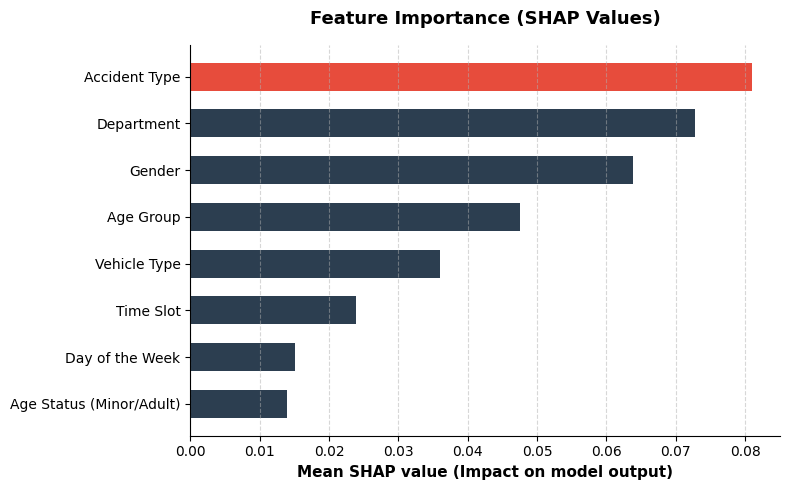

In [7]:
# -- SHAP Summary Plot (IEEE Style) ----------------------------------

# 1. Asegúrate de que las columnas tengan el mismo orden que cuando entrenaste
# Extraemos los nombres en el orden correcto
feature_names = [LABELS[f] for f in FEATURES] 

# 2. Calculamos los valores SHAP promedio
shap_values_mean = np.abs(shap_values.values[:, :, 0]).mean(axis=0)

# 3. Creamos el DataFrame usando listas, NO el diccionario directamente
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP': shap_values_mean
}).sort_values('SHAP', ascending=True)

# El resto del código se mantiene igual
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2c3e50' if x < shap_df['SHAP'].max() else '#e74c3c' for x in shap_df['SHAP']]

bars = ax.barh(shap_df['Feature'], shap_df['SHAP'], 
               color=colors, edgecolor='none', height=0.6)

ax.set_xlabel('Mean SHAP value (Impact on model output)', fontsize=11, fontweight='bold')
ax.set_title('Feature Importance (SHAP Values)', fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../data/models/shap_summary_ieee.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretación SHAP : Importancia global

El análisis SHAP revela que el **Tipo de evento** es el factor más determinante
en la predicción de fallecimiento, seguido del **Departamento** y el **Sexo**.

Esto es consistente con la literatura , un vuelco o atropello tiene mayor
probabilidad de fatalidad que una colisión leve, y ciertas rutas departamentales
concentran mayor severidad por velocidades permitidas más altas.

El **Tipo de vehículo** ocupa el quinto lugar , confirmando que las motocicletas
son más vulnerables pero el tipo de evento las supera como predictor principal.

## 4. SHAP Beeswarm Plot : Impacto por valor de feature

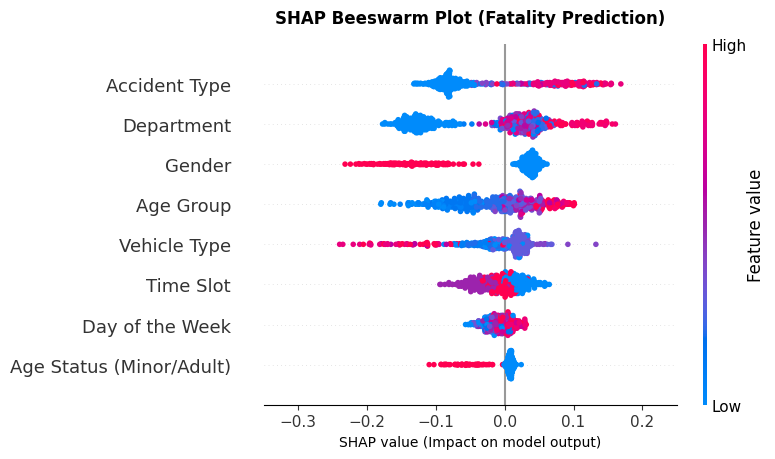

✓ Beeswarm plot saved for the paper


In [8]:
# -- SHAP Beeswarm Plot (IEEE Style) ----------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# 1. Definimos las etiquetas en inglés para que SHAP las tome automáticamente
# Es importante que el feature_names coincida con tu lista traducida
shap_class0 = shap.Explanation(
    values=shap_values.values[:, :, 0],
    base_values=shap_values.base_values[:, 0],
    data=X_sample.values,
    feature_names=[LABELS[f] for f in FEATURES] 
)

# 2. Generamos el plot
shap.plots.beeswarm(
    shap_class0,
    show=False,
    max_display=8
)

# 3. Ajustes de estilo IEEE
plt.title('SHAP Beeswarm Plot (Fatality Prediction)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('SHAP value (Impact on model output)', fontsize=10)

# Ajuste de límites para que los puntos no se corten
plt.xlim(-0.35, 0.25)

# Aumentar resolución para el paper
plt.tight_layout()
plt.savefig('../data/models/shap_beeswarm_ieee.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Beeswarm plot saved for the paper')

### Interpretación SHAP Beeswarm

- Puntos a la **derecha** (+) aumentan probabilidad de Fallecido
- Puntos a la **izquierda** (-) aumentan probabilidad de Lesionado
- Color **rojo** = valor alto de la variable
- Color **azul** = valor bajo de la variable

**Hallazgos clave:**
- Tipos de evento específicos (atropello, vuelco) elevan severidad
- Departamentos con rutas de alta velocidad aumentan fatalidad
- Motocicletas (tipo vehículo bajo) incrementan riesgo de fallecimiento

## 5. SHAP Waterfall : Explicación de predicción individual

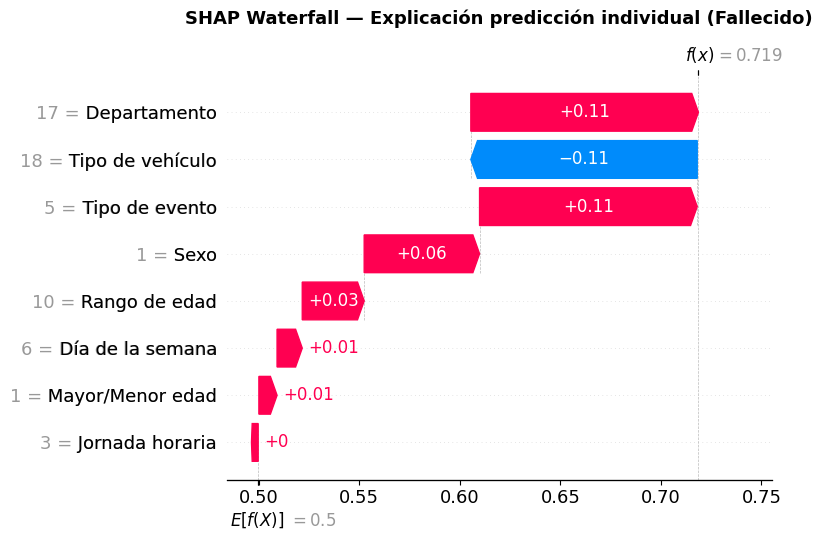

✓ Waterfall guardado


In [ ]:
# -- SHAP Waterfall — caso individual ----------------------------------------------
# Tomamos un caso de fallecido real
idx_fallecido = X_sample[y_test.loc[X_sample.index] == 1].index[0]
pos = X_sample.index.get_loc(idx_fallecido)

shap.plots.waterfall(
    shap_class0[pos],
    show=False,
    max_display=8
)

plt.title('SHAP Waterfall : Explicación predicción individual (Fallecido)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/models/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Waterfall guardado')

### Interpretación SHAP Waterfall

El waterfall explica por qué el modelo predijo **Fallecido** para este caso:

- Probabilidad base del modelo: **0.50**
- Departamento 17 (Zacapa) aumenta +0.11 el riesgo
- Tipo de evento 5 (Colisión) aumenta +0.11 el riesgo  
- Tipo de vehículo 18 reduce -0.11 el riesgo
- Probabilidad final: **71.9%** de Fallecido

Esta explicación individual permite auditar cada predicción del modelo,
garantizando transparencia en la toma de decisiones.